In [1]:
import yfinance as yf
import pandas_datareader.data as web

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [15]:
metals = pd.read_csv('precious_metals.csv')
metals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1299 entries, 0 to 1298
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         1299 non-null   object 
 1   GC=F Close   1299 non-null   float64
 2   HG=F Close   1299 non-null   float64
 3   PA=F Close   1299 non-null   float64
 4   PL=F Close   1299 non-null   float64
 5   SI=F Close   1299 non-null   float64
 6   SLAB Close   1299 non-null   float64
 7   GC=F High    1299 non-null   float64
 8   HG=F High    1299 non-null   float64
 9   PA=F High    1299 non-null   float64
 10  PL=F High    1299 non-null   float64
 11  SI=F High    1299 non-null   float64
 12  SLAB High    1299 non-null   float64
 13  GC=F Low     1299 non-null   float64
 14  HG=F Low     1299 non-null   float64
 15  PA=F Low     1299 non-null   float64
 16  PL=F Low     1299 non-null   float64
 17  SI=F Low     1299 non-null   float64
 18  SLAB Low     1299 non-null   float64
 19  GC=F O

In [17]:
## Modify date columns
metals['Date'] = pd.to_datetime(metals["Date"])
metals['Day'] = metals['Date'].dt.weekday
metals['Month'] = metals['Date'].dt.month
metals['Month Name'] = metals['Date'].dt.month_name()
metals['Year'] = metals['Date'].dt.year

In [ ]:
# tickers = np.unique([col.split()[0] for col in list(metals.columns) if "=" in col])

# daily_spread = pd.DataFrame()
# daily_spread['Date'] = metals.Date

# for tick in tickers:
#     daily_spread[tick+' Volume Range'] = pd.cut(metals[tick + ' Volume'],bins=5,labels=[x for x in range(5)])

In [139]:
volumes = metals.iloc[:,-10:].groupby('Month Name')[['GC=F Volume',
                                   	'HG=F Volume',
                                        	'PA=F Volume',
                                                	'PL=F Volume',
                                                        	'SI=F Volume']].mean()

In [161]:
volume_melt = pd.melt(metals,
        id_vars=['Year','Month Name'],
        value_vars=['GC=F Volume','HG=F Volume','PA=F Volume','PL=F Volume','SI=F Volume'],
        var_name="Ticker",
        value_name="Total"
        )

In [162]:
volume_melt

,Year,Month Name,Ticker,Total
0,2020,January,GC=F Volume,214.0
1,2020,January,GC=F Volume,107.0
2,2020,January,GC=F Volume,416.0
3,2020,January,GC=F Volume,47.0
4,2020,January,GC=F Volume,236.0
...,...,...,...,...
6490,2025,February,SI=F Volume,36515.0
6491,2025,February,SI=F Volume,10140.0
6492,2025,February,SI=F Volume,1641.0
6493,2025,March,SI=F Volume,872.0


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

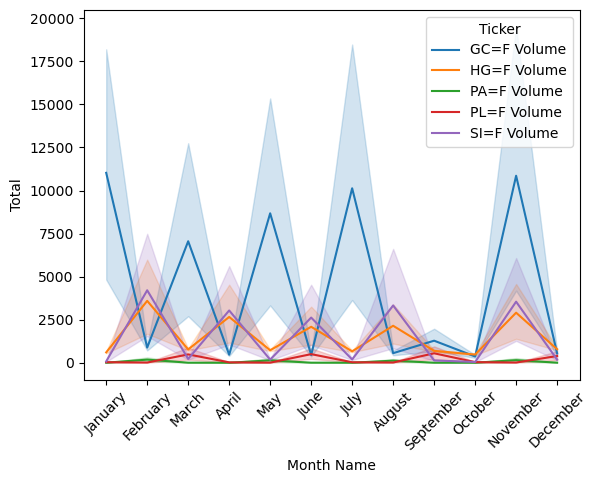

In [170]:
sns.lineplot(data=volume_melt,x='Month Name',y='Total',hue='Ticker')
plt.xticks(rotation=45)

In [123]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler


In [136]:
scaler = StandardScaler()
vol = pd.DataFrame(data=scaler.fit_transform(volumes),columns=volumes.columns)